# Análise Exploratória 

### Dicionário das variáveis

| Coluna | Tipo | Descrição |
|---|---|---|
| id_campanha | str | Identificador único da campanha |
| data | date | Data de veiculação |
| plataforma | cat | Meta / TikTok / LinkedIn / YouTube |
| categoria | cat | Segmento do anunciante |
| objetivo | cat | Objetivo da campanha (awareness, tráfego, etc.) |
| faixa_etaria_alvo | cat | Público-alvo por faixa etária |
| e_retargeting | bool | Campanha de retargeting? |
| duracao_video_s | float | Duração do vídeo em segundos |
| formato | cat | Formato do criativo (vertical, horizontal, quadrado) |
| tem_legenda | bool | Tem legenda? |
| tem_cta | bool | Tem call-to-action? |
| tem_hook | bool | Tem hook nos primeiros 3 segundos? |
| tem_rosto | bool | Há rosto humano no criativo? |
| densidade_texto | cat | Quantidade de texto: low / medium / high |
| proporcao_musica_voz | float | Razão música/voz (0=só voz, 1=só música) |
| impressoes | int | Número de impressões |
| cliques | int | Número de cliques |
| taxa_cliques | float | CTR = cliques / impressões |
| custo_por_clique | float | CPC em R$ |
| gasto | float | Investimento total em R$ |
| conversoes | int | Número de conversões |
| receita | float | Receita gerada em R$ |
| roas | float | Return on Ad Spend = receita / gasto |
| tempo_medio_visualizacao_s | float | Tempo médio assistido em segundos |
| taxa_engajamento | float | Engajamento = interações / impressões |
| pontuacao_klike | float | Score proprietário Klike (0–100) |

## 0. Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

SEED = 42
np.random.seed(SEED)

## 1. Carga dos dados

In [2]:
df = pd.read_csv('klike_challenge_dataset_pt.csv', parse_dates=['data'])

print(f'Shape: {df.shape}  →  {df.shape[0]} campanhas × {df.shape[1]} variáveis')
df.head()

Shape: (500, 26)  →  500 campanhas × 26 variáveis


,id_campanha,data,plataforma,categoria,objetivo,faixa_etaria_alvo,e_retargeting,duracao_video_s,formato,tem_legenda,...,cliques,taxa_cliques,custo_por_clique,gasto,conversoes,receita,roas,tempo_medio_visualizacao_s,taxa_engajamento,pontuacao_klike
0,KLK-0001,2024-01-01,Meta,Branding,awareness,18-24,False,NaN,vertical,True,...,5882,0.0390,0.82,4823.24,48,0.00,0.00,3.9,0.0446,63.6
1,KLK-0002,2024-03-22,LinkedIn,App Install,traffic,25-34,False,NaN,horizontal,True,...,493,0.0664,3.54,1745.22,34,NaN,0.16,6.4,0.0217,70.0
2,KLK-0003,2024-05-04,TikTok,SaaS,traffic,25-34,False,8.0,vertical,True,...,15069,0.0780,0.38,5726.22,492,51053.44,8.92,8.0,0.1000,99.1
3,KLK-0004,2024-12-27,TikTok,Lead Gen,engagement,25-34,False,27.0,quadrado,False,...,601,0.0925,0.71,426.71,19,1113.78,2.61,20.3,0.0414,74.9
4,KLK-0005,2024-07-10,Meta,Branding,engagement,25-34,False,34.0,vertical,True,...,2355,0.0369,0.38,894.90,13,0.00,0.00,34.0,0.0184,77.9


In [3]:
df.dtypes 

id_campanha                           object
data                          datetime64[ns]
plataforma                            object
categoria                             object
objetivo                              object
faixa_etaria_alvo                     object
e_retargeting                           bool
duracao_video_s                      float64
formato                               object
tem_legenda                           object
tem_cta                                 bool
tem_hook                                bool
tem_rosto                               bool
densidade_texto                       object
proporcao_musica_voz                 float64
impressoes                             int64
cliques                                int64
taxa_cliques                         float64
custo_por_clique                     float64
gasto                                float64
conversoes                             int64
receita                              float64
roas      

## 2. Qualidade dos dados

Identificação dos valores ausentes e inconsistências nos dados

In [5]:
missing = (
    df.isnull()
      .sum()
      .rename('num_nulos')
      .to_frame()
      .assign(pct_nulos=lambda x: (x['num_nulos'] / len(df) * 100).round(1))
      .query('num_nulos > 0')
      .sort_values('num_nulos', ascending=False)
)
print('Colunas com valores ausentes: ')
missing

Colunas com valores ausentes: 


,num_nulos,pct_nulos
tem_legenda,46,9.2
duracao_video_s,39,7.8
proporcao_musica_voz,38,7.6
taxa_engajamento,32,6.4
custo_por_clique,28,5.6
tempo_medio_visualizacao_s,27,5.4
receita,25,5.0


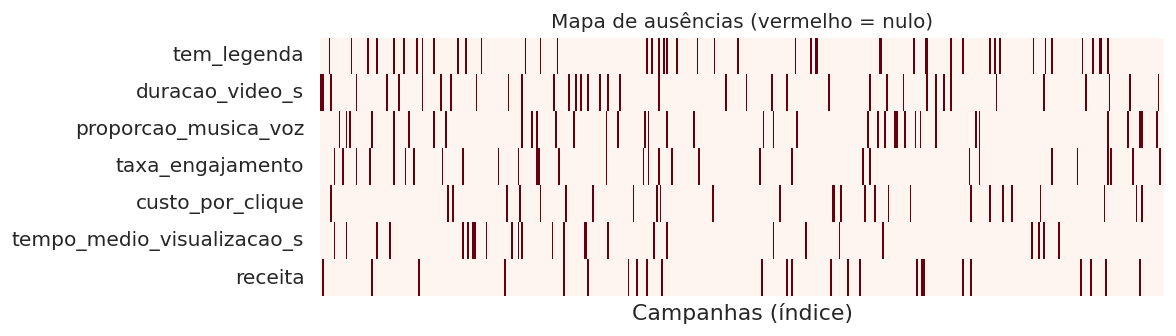

In [8]:
# Visualização do padrão de ausência para detectar se faltam em bloco (erro de coleta) ou ta aleatório
# No caso, se os nulos aparecem espalhados (não em bloco)
# são Missing At Random e podemos ignorar ou usar as técnicas de imputação simples (média, moda)
ig, ax = plt.subplots(figsize=(10, 3))
cols_com_nulo = missing.index.tolist()
miss_matrix = df[cols_com_nulo].isnull().astype(int)
sns.heatmap(miss_matrix.T, cbar=False, cmap='Reds', ax=ax,
            xticklabels=False, yticklabels=cols_com_nulo)
ax.set_title('Mapa de ausências (vermelho = nulo)', fontsize=12)
ax.set_xlabel('Campanhas (índice)')
plt.tight_layout()
plt.show()

In [10]:
n_dup = df.duplicated().sum()
print(f'Numero de linhas duplicadas: {n_dup}')

ctr_calculado = df['cliques'] / df['impressoes']
erro_ctr = (ctr_calculado - df['taxa_cliques']).abs()
print(f'Erro máximo CTR vs. cliques/impressões: {erro_ctr.max():.6f}  (tolerância 0.001)')

inconsistencia_roas = df[(df['receita'] > 0) & (df['roas'] == 0)]
print(f'Campanhas com receita > 0 e ROAS = 0: {len(inconsistencia_roas)}')

Numero de linhas duplicadas: 0
Erro máximo CTR vs. cliques/impressões: 0.042312  (tolerância 0.001)
Campanhas com receita > 0 e ROAS = 0: 0


In [35]:
# Como has_subtitle lida como string então deveria ser bool 
# (Pandas leu como object porque tem valores True/False misturados com NaN)
# Enão convertemos: True=True, False=False, NaN =NaN
print('Valores de has_subtitle:', df['tem_legenda'].unique())
df['tem_legenda'] = df['tem_legenda'].replace({'True': True, 'False': False})
print(df['tem_legenda'])

Valores de has_subtitle: [True False nan]
0       True
1       True
2       True
3      False
4       True
       ...  
495    False
496    False
497     True
498     True
499     True
Name: tem_legenda, Length: 500, dtype: object


## 3. Estatísticas descritivas

In [36]:
# Variáveis numéricas com transposto para facilitar leitura porque tem muitas colunas
num_cols = df.select_dtypes(include='number').columns.tolist()
df[num_cols].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
duracao_video_s,461.0,19.39,13.53,5.00,11.00,16.00,25.00,115.00
proporcao_musica_voz,462.0,0.40,0.20,0.02,0.23,0.38,0.55,0.92
impressoes,500.0,153738.52,1171735.61,1000.00,9986.00,23241.00,55172.75,14052761.00
cliques,500.0,3594.10,7018.21,4.00,461.75,1351.00,3583.25,72545.00
taxa_cliques,500.0,0.07,0.05,0.00,0.03,0.06,0.10,0.15
custo_por_clique,472.0,1.11,1.96,0.05,0.53,0.71,1.02,26.05
gasto,500.0,4213.15,11573.98,2.96,313.45,1031.00,2867.95,121226.10
conversoes,500.0,131.35,314.57,0.00,10.00,34.50,111.00,3666.00
receita,475.0,6367.94,19267.18,0.00,262.18,1201.05,4189.02,241597.29
roas,500.0,2.50,3.59,0.00,0.43,1.49,3.25,39.92


In [21]:
cat_cols = ['plataforma', 'categoria', 'objetivo', 'faixa_etaria_alvo', 'formato', 'densidade_texto']
for col in cat_cols:
    print(df[col].value_counts())
    print('\n')

plataforma
Meta        241
TikTok      176
LinkedIn     83
Name: count, dtype: int64


categoria
E-commerce     165
SaaS            97
Lead Gen        93
App Install     82
Branding        63
Name: count, dtype: int64


objetivo
conversions    165
traffic        150
engagement      79
awareness       60
app_install     46
Name: count, dtype: int64


faixa_etaria_alvo
25-34    143
35-44    139
18-24    137
45+       81
Name: count, dtype: int64


formato
vertical      269
quadrado      120
horizontal    111
Name: count, dtype: int64


densidade_texto
medium    230
low       179
high       91
Name: count, dtype: int64




## 4. Distribuições das variáveis numéricas

Analise gráfica: os histogramas mostram a frequência; KDE suaviza e revela bimodalidade ou caudas longas (skew); para contar a história completa da distribuição.

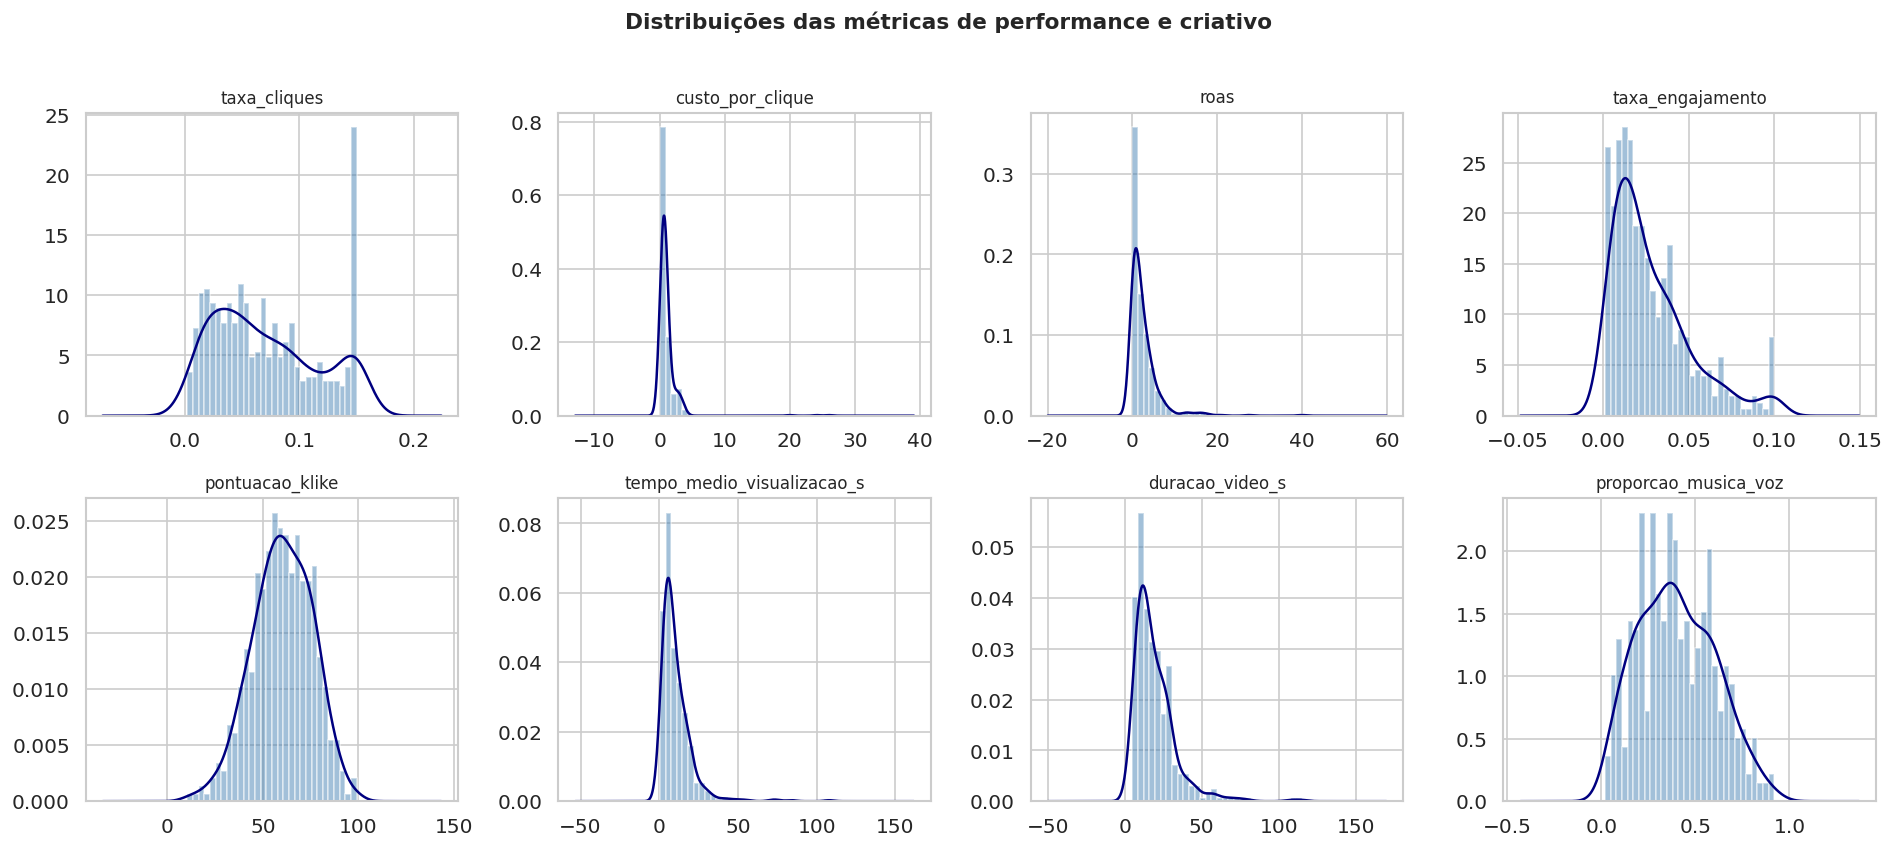

In [37]:
metricas = ['taxa_cliques', 'custo_por_clique', 'roas', 'taxa_engajamento',
            'pontuacao_klike', 'tempo_medio_visualizacao_s', 'duracao_video_s',
            'proporcao_musica_voz']

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for ax, col in zip(axes, metricas):
    dados = df[col].dropna()
    ax.hist(dados, bins=30, density=True, alpha=0.5, color='steelblue', edgecolor='white')
    dados.plot.kde(ax=ax, color='navy', linewidth=1.5)
    ax.set_title(col, fontsize=10)
    ax.set_xlabel('')
    ax.set_ylabel('')

plt.suptitle('Distribuições das métricas de performance e criativo', y=1.01, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Análise univariada (variáveis categóricas)

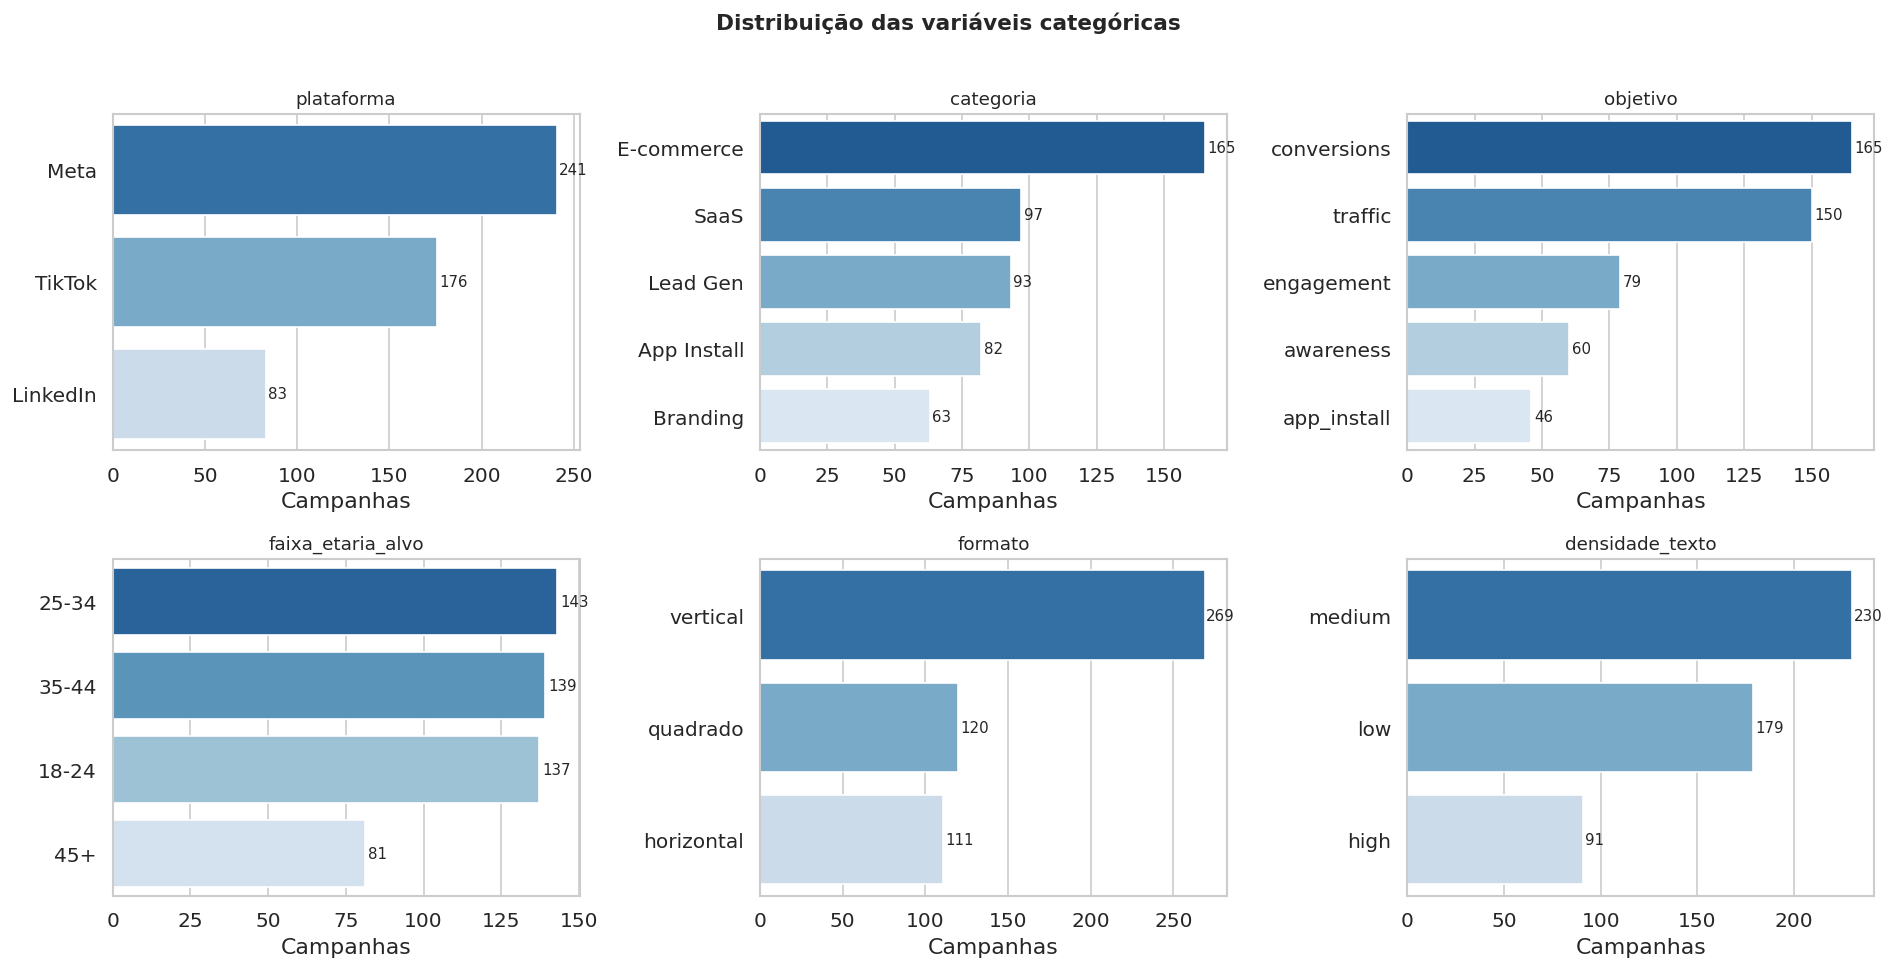

In [38]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
# discovery sobre o equilíbrio (ou desequilíbrio) do dataset porque um grupo muito dominante pode enviesar as conclusões
for ax, col in zip(axes, cat_cols):
    contagem = df[col].value_counts()
    sns.barplot(x=contagem.values, y=contagem.index, ax=ax, palette='Blues_r')
    ax.set_title(col, fontsize=11)
    ax.set_xlabel('Campanhas')
    ax.set_ylabel('')
    for p, v in zip(ax.patches, contagem.values):
        ax.text(p.get_width() + 1, p.get_y() + p.get_height() / 2,
                f'{v}', va='center', fontsize=9)

plt.suptitle('Distribuição das variáveis categóricas', y=1.01, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

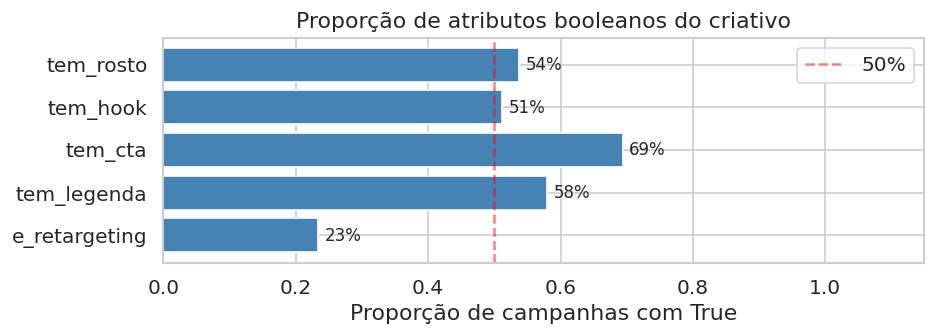

In [39]:
bool_cols = ['e_retargeting', 'tem_legenda', 'tem_cta', 'tem_hook', 'tem_rosto']

proporcoes = df[bool_cols].apply(lambda s: s.dropna().map({True: 1, False: 0}).mean())

fig, ax = plt.subplots(figsize=(8, 3))
bars = ax.barh(proporcoes.index, proporcoes.values, color='steelblue')
ax.set_xlim(0, 1.15)
ax.axvline(0.5, color='red', linestyle='--', alpha=0.5, label='50%')
ax.set_xlabel('Proporção de campanhas com True')
ax.set_title('Proporção de atributos booleanos do criativo')
for bar, val in zip(bars, proporcoes.values):
    ax.text(val + 0.01, bar.get_y() + bar.get_height() / 2,
            f'{val:.0%}', va='center', fontsize=10)
ax.legend()
plt.tight_layout()
plt.show()

## 6. Análise temporal

Verificação da sazonalidade, crescimento/concentração de campanhas em períodos específicos

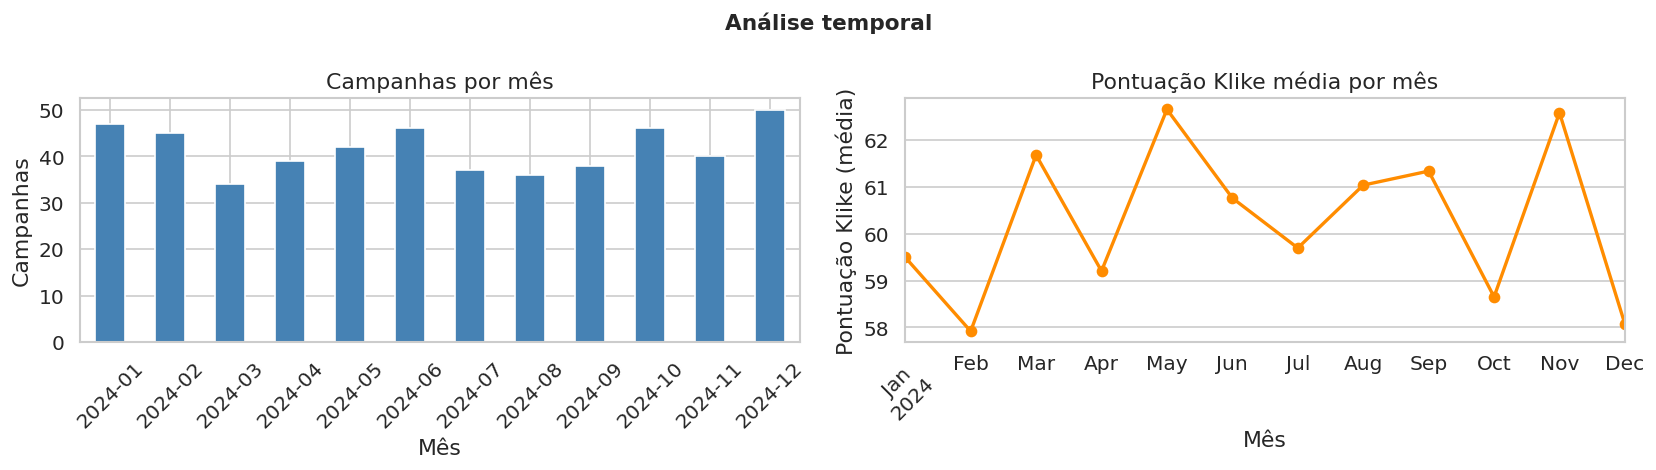

In [40]:
df['mes'] = df['data'].dt.to_period('M')
camp_por_mes = df.groupby('mes').size()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

camp_por_mes.plot(ax=axes[0], kind='bar', color='steelblue', edgecolor='white')
axes[0].set_title('Campanhas por mês')
axes[0].set_xlabel('Mês')
axes[0].set_ylabel('Campanhas')
axes[0].tick_params(axis='x', rotation=45)

klike_mes = df.groupby('mes')['pontuacao_klike'].mean()
klike_mes.plot(ax=axes[1], marker='o', color='darkorange', linewidth=2)
axes[1].set_title('Pontuação Klike média por mês')
axes[1].set_xlabel('Mês')
axes[1].set_ylabel('Pontuação Klike (média)')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Análise temporal', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Performance por plataforma

> **Dúvida a ser respondida:** Qual plataforma entrega mais valor? 

In [41]:
# Mediana é mais robusta que a média na presença de outliers
perf_plataforma = (
    df.groupby('plataforma')[['taxa_cliques', 'custo_por_clique', 'roas', 'pontuacao_klike']]
      .median()
      .round(3)
      .sort_values('pontuacao_klike', ascending=False)
)
print('Mediana por plataforma: ')
perf_plataforma

Mediana por plataforma: 


,taxa_cliques,custo_por_clique,roas,pontuacao_klike
plataforma,,,,
TikTok,0.056,0.520,2.635,62.0
Meta,0.065,0.820,1.620,60.5
LinkedIn,0.067,2.555,0.530,57.2


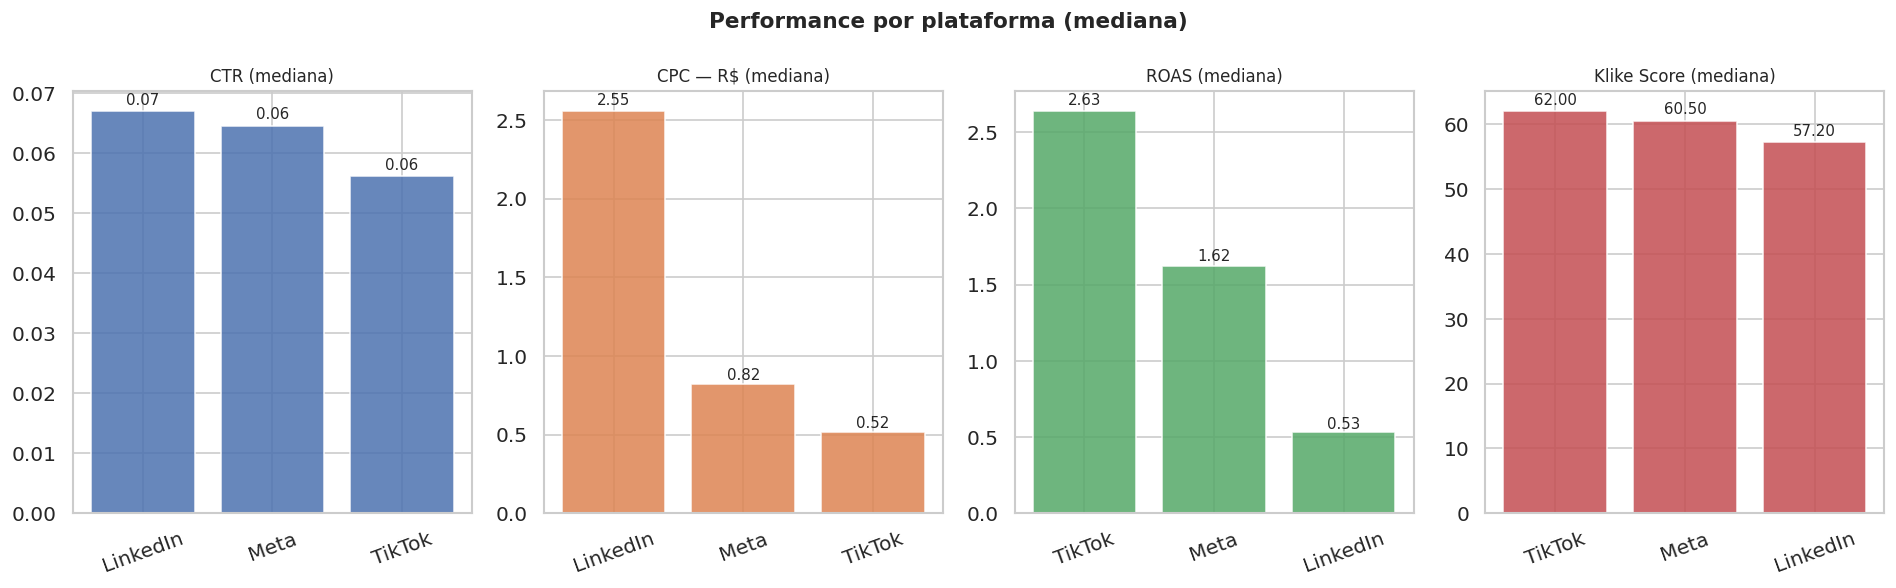

In [42]:
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
metricas_plat = ['taxa_cliques', 'custo_por_clique', 'roas', 'pontuacao_klike']
titulos = ['CTR (mediana)', 'CPC — R$ (mediana)', 'ROAS (mediana)', 'Klike Score (mediana)']
cores = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

for ax, col, titulo, cor in zip(axes, metricas_plat, titulos, cores):
    dados_plot = df.groupby('plataforma')[col].median().sort_values(ascending=False)
    bars = ax.bar(dados_plot.index, dados_plot.values, color=cor, alpha=0.85)
    ax.set_title(titulo, fontsize=10)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=20)
    for bar, val in zip(bars, dados_plot.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.01,
                f'{val:.2f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Performance por plataforma (mediana)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

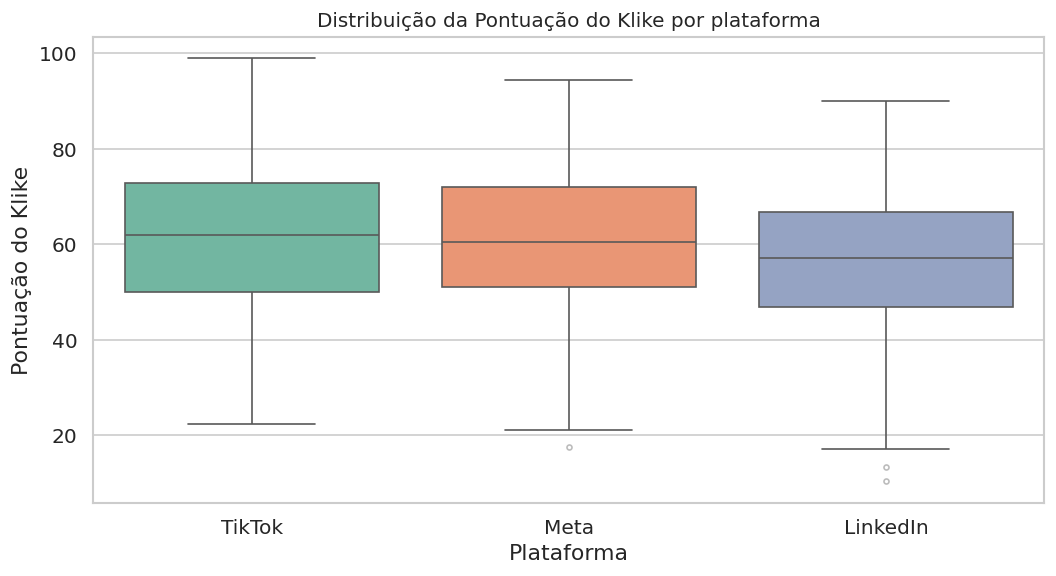

In [43]:
fig, ax = plt.subplots(figsize=(9, 5))
ordem = df.groupby('plataforma')['pontuacao_klike'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='plataforma', y='pontuacao_klike', order=ordem,
            palette='Set2', ax=ax, showfliers=True,
            flierprops=dict(marker='o', markersize=3, alpha=0.4))
ax.set_title('Distribuição da Pontuação do Klike por plataforma', fontsize=12)
ax.set_xlabel('Plataforma')
ax.set_ylabel('Pontuação do Klike')
plt.tight_layout()
plt.show()

## 8. Impacto dos atributos criativos

In [46]:
# Para cada atributo booleano, calculamos a diferença na mediana da Klike Score entre True e False
# com o objetivo de identificar quais características do criativo têm maior impacto na performance (Klike Score)
resultados = []
for col in bool_cols:
    grupo    = df[[col, 'pontuacao_klike']].dropna()
    medianas = grupo.groupby(col)['pontuacao_klike'].median()
    resultados.append({
        'atributo':     col,
        'com_atributo': medianas.get(True),
        'sem_atributo': medianas.get(False),
        'delta':        medianas.get(True) - medianas.get(False),
    })

df_impact = pd.DataFrame(resultados).sort_values('delta', ascending=False)
df_impact

,atributo,com_atributo,sem_atributo,delta
3,tem_hook,69.55,52.25,17.3
4,tem_rosto,66.30,54.90,11.4
2,tem_cta,62.70,55.40,7.3
1,tem_legenda,63.70,58.00,5.7
0,e_retargeting,62.40,59.90,2.5


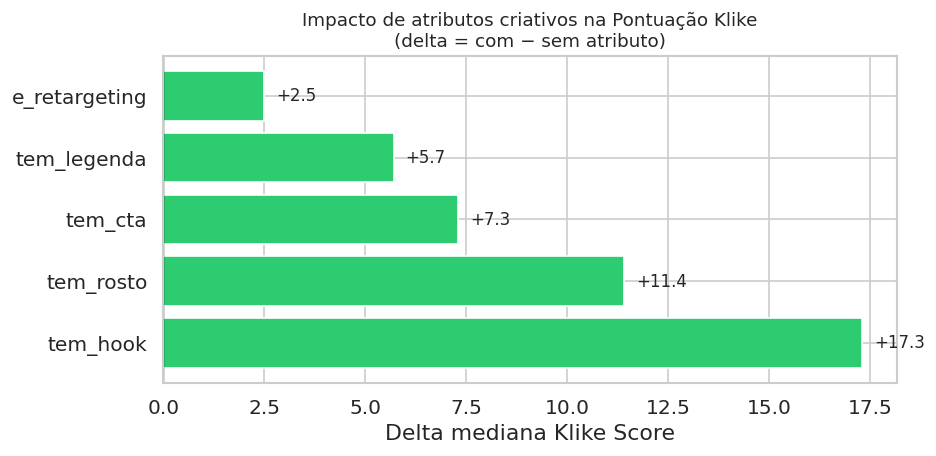

In [47]:
fig, ax = plt.subplots(figsize=(8, 4))
cores_delta = ['#2ecc71' if d > 0 else '#e74c3c' for d in df_impact['delta']]
bars = ax.barh(df_impact['atributo'], df_impact['delta'], color=cores_delta)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Impacto de atributos criativos na Pontuação Klike\n(delta = com − sem atributo)', fontsize=11)
ax.set_xlabel('Delta mediana Klike Score')
for bar, val in zip(bars, df_impact['delta']):
    ax.text(val + (0.3 if val >= 0 else -0.3),
            bar.get_y() + bar.get_height() / 2,
            f'{val:+.1f}', va='center', fontsize=10)
plt.tight_layout()
plt.show()

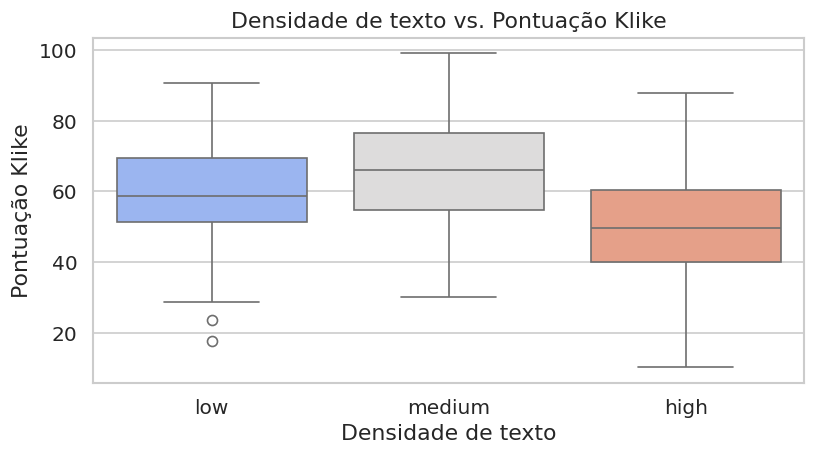

In [48]:
fig, ax = plt.subplots(figsize=(7, 4))
ordem_dens = ['low', 'medium', 'high']
sns.boxplot(data=df, x='densidade_texto', y='pontuacao_klike',
            order=ordem_dens, palette='coolwarm', ax=ax)
ax.set_title('Densidade de texto vs. Pontuação Klike')
ax.set_xlabel('Densidade de texto')
ax.set_ylabel('Pontuação Klike')
plt.tight_layout()
plt.show()

## 9. Correlações

O Pearson captura relações lineares entre variáveis numéricas. 
A Klike Score é nesse caso a variável-alvo e dsejamos ver o que mais se correlaciona com ela.

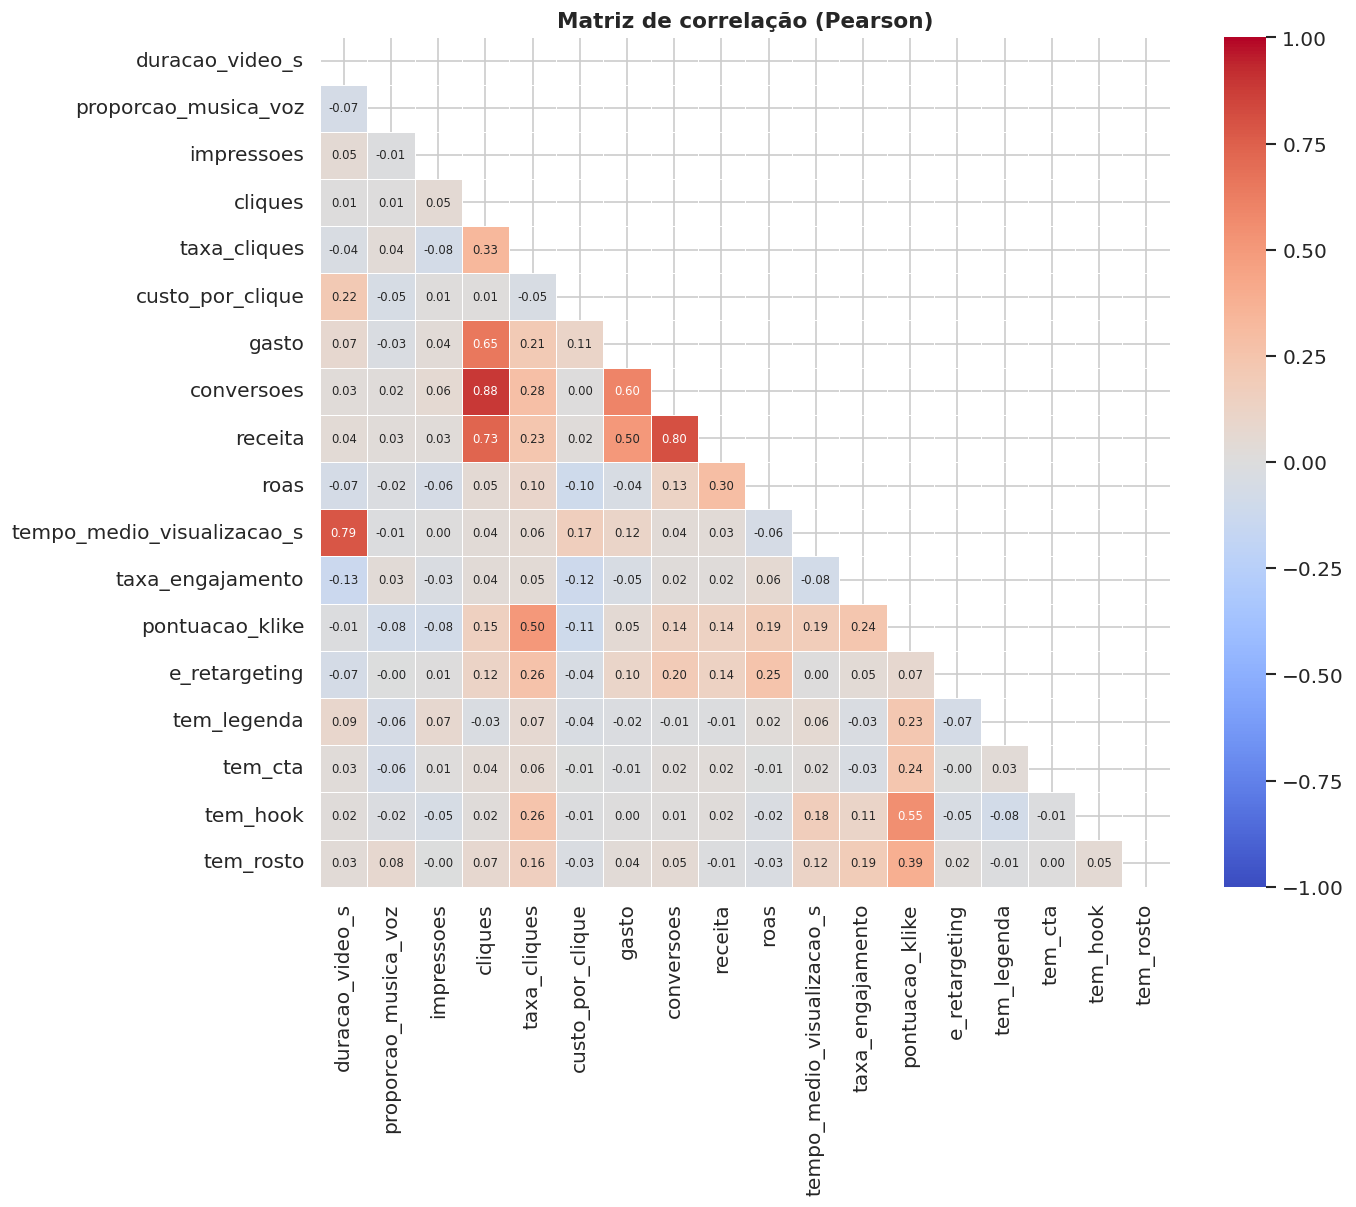

In [49]:
# Convertemos booleanos para 0/1 para entrar na correlação
df_corr = df[num_cols].copy()
for col in bool_cols:
    df_corr[col] = df[col].map({True: 1, False: 0, 'True': 1, 'False': 0})

corr = df_corr.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))  # Mostra só metade inferior (a outra é espelho)
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, square=True,
            linewidths=0.4, ax=ax, annot_kws={'size': 7})
ax.set_title('Matriz de correlação (Pearson)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

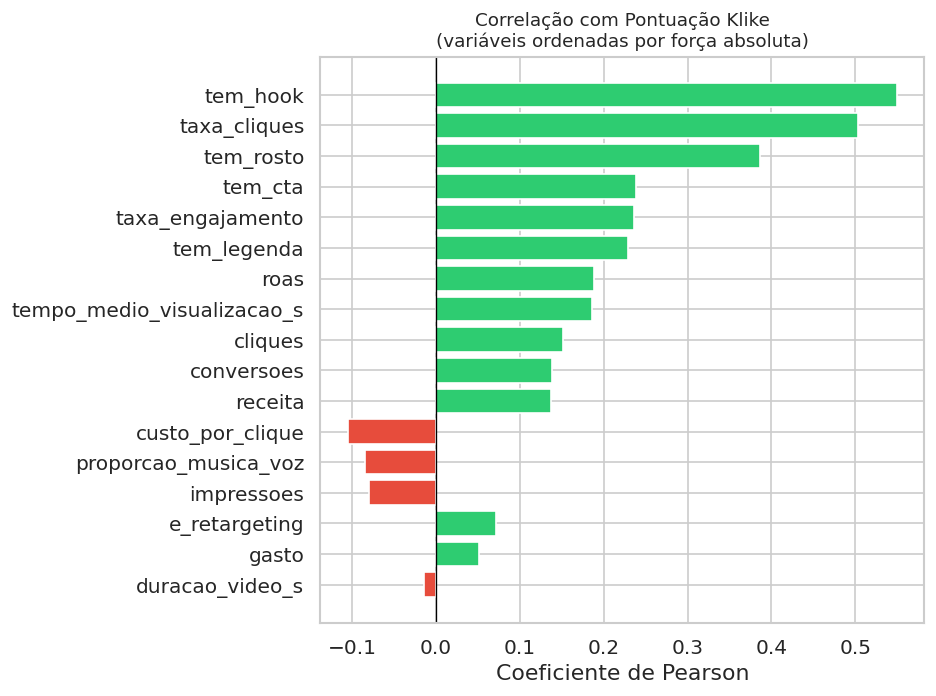

In [51]:
correlacao_klike = (
    corr['pontuacao_klike']
    .drop('pontuacao_klike')  # remove a autocorrelação
    .sort_values(key=abs, ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 6))
cores_corr = ['#2ecc71' if v > 0 else '#e74c3c' for v in correlacao_klike]
bars = ax.barh(correlacao_klike.index[::-1], correlacao_klike.values[::-1], color=cores_corr[::-1])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Correlação com Pontuação Klike\n(variáveis ordenadas por força absoluta)', fontsize=11)
ax.set_xlabel('Coeficiente de Pearson')
plt.tight_layout()
plt.show()

## 10. Análise de outliers

Os outliers em ROAS e gasto podem ser erros de dados e identificá-los evita que distorçam médias e modelos futuros.

In [52]:
# Uso de IQR  porque é robusto a outliers e não assume normalidade
def outliers_iqr(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    return series[(series < q1 - 1.5 * iqr) | (series > q3 + 1.5 * iqr)]

metricas_outlier = ['roas', 'gasto', 'custo_por_clique', 'taxa_cliques', 'pontuacao_klike']

resumo_outliers = pd.DataFrame({
    'n_outliers': {c: len(outliers_iqr(df[c].dropna())) for c in metricas_outlier},
    'pct_outliers': {c: len(outliers_iqr(df[c].dropna())) / df[c].notna().sum() * 100 for c in metricas_outlier},
    'max_valor': {c: df[c].max() for c in metricas_outlier},
    'whisker_sup': {c: df[c].quantile(0.75) + 1.5 * (df[c].quantile(0.75) - df[c].quantile(0.25)) for c in metricas_outlier},
}).round(2)
resumo_outliers

,n_outliers,pct_outliers,max_valor,whisker_sup
roas,27,5.40,39.92,7.48
gasto,61,12.20,121226.10,6699.70
custo_por_clique,66,13.98,26.05,1.76
taxa_cliques,0,0.00,0.15,0.21
pontuacao_klike,2,0.40,99.10,105.15


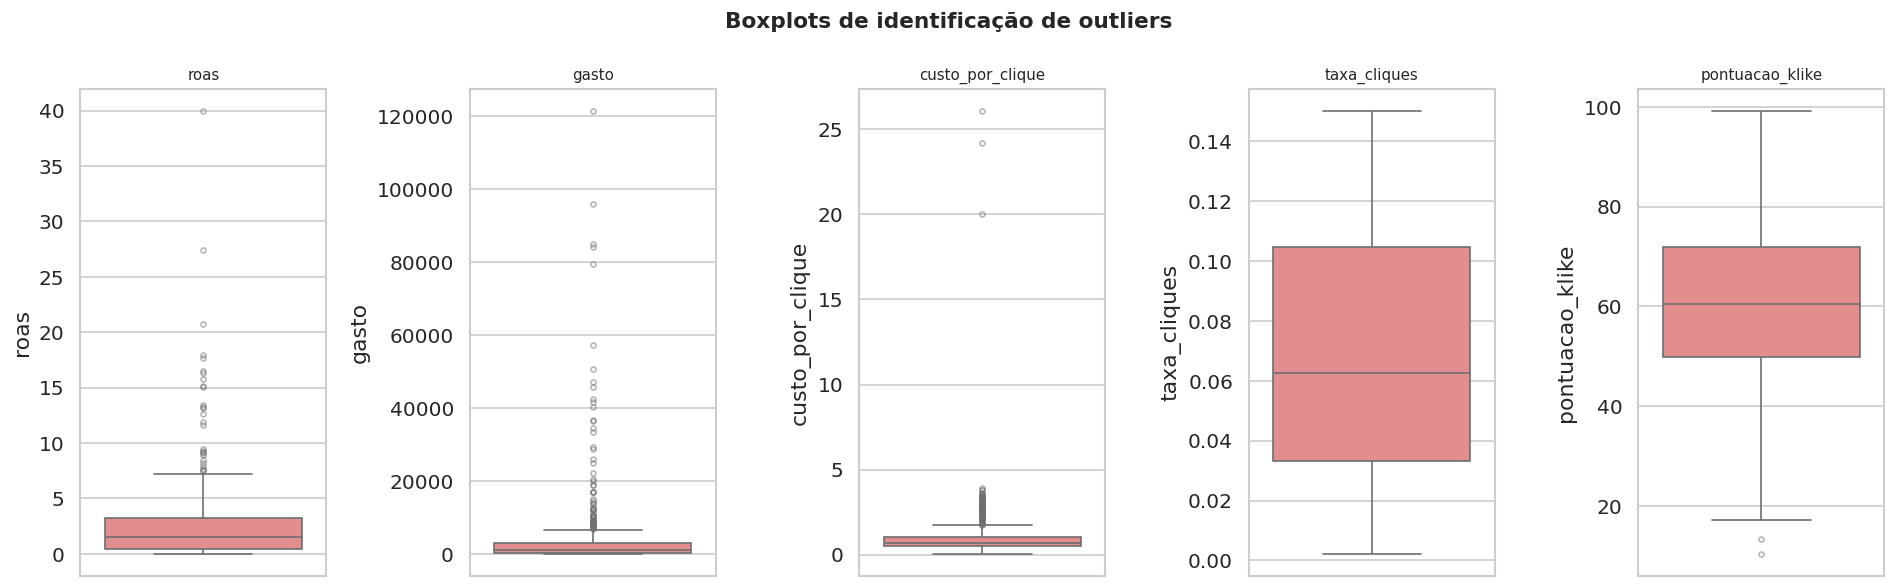

In [53]:
fig, axes = plt.subplots(1, 5, figsize=(16, 5))
for ax, col in zip(axes, metricas_outlier):
    sns.boxplot(y=df[col].dropna(), ax=ax, color='lightcoral',
                flierprops=dict(marker='o', markersize=3, alpha=0.5))
    ax.set_title(col, fontsize=9)
    ax.set_xlabel('')
plt.suptitle('Boxplots de identificação de outliers', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 11. Análise bivariada

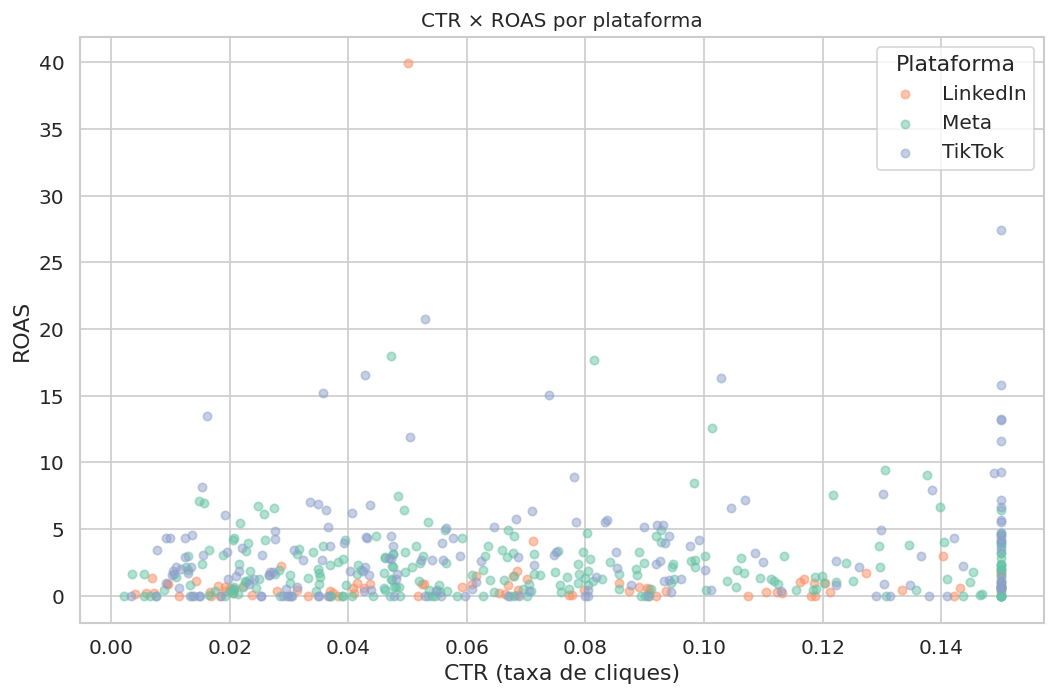

In [54]:
# as campanhas caras de clicar entregam mais retorno?
fig, ax = plt.subplots(figsize=(9, 6))
plataformas = df['plataforma'].unique()
palette = dict(zip(plataformas, sns.color_palette('Set2', len(plataformas))))

for plat, group in df.groupby('plataforma'):
    ax.scatter(group['taxa_cliques'], group['roas'],
               label=plat, alpha=0.5, s=25, color=palette[plat])

ax.set_xlabel('CTR (taxa de cliques)')
ax.set_ylabel('ROAS')
ax.set_title('CTR × ROAS por plataforma', fontsize=12)
ax.legend(title='Plataforma')
plt.tight_layout()
plt.show()

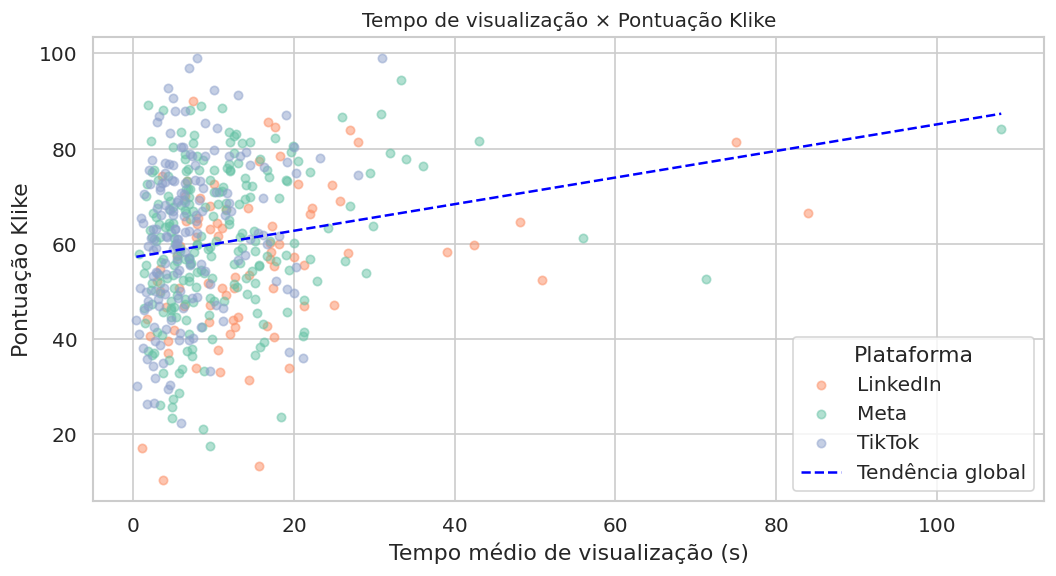

In [57]:
# o engajamento com o vídeo reflete no score?
fig, ax = plt.subplots(figsize=(9, 5))
for plat, group in df.groupby('plataforma'):
    ax.scatter(group['tempo_medio_visualizacao_s'], group['pontuacao_klike'],
               label=plat, alpha=0.5, s=25, color=palette[plat])

valid = df[['tempo_medio_visualizacao_s', 'pontuacao_klike']].dropna()
m, b = np.polyfit(valid['tempo_medio_visualizacao_s'], valid['pontuacao_klike'], 1)
x_line = np.linspace(valid['tempo_medio_visualizacao_s'].min(), valid['tempo_medio_visualizacao_s'].max(), 100)
ax.plot(x_line, m * x_line + b, color='blue', linewidth=1.5, linestyle='--', label='Tendência global')

ax.set_xlabel('Tempo médio de visualização (s)')
ax.set_ylabel('Pontuação Klike')
ax.set_title('Tempo de visualização × Pontuação Klike', fontsize=12)
ax.legend(title='Plataforma')
plt.tight_layout()
plt.show()

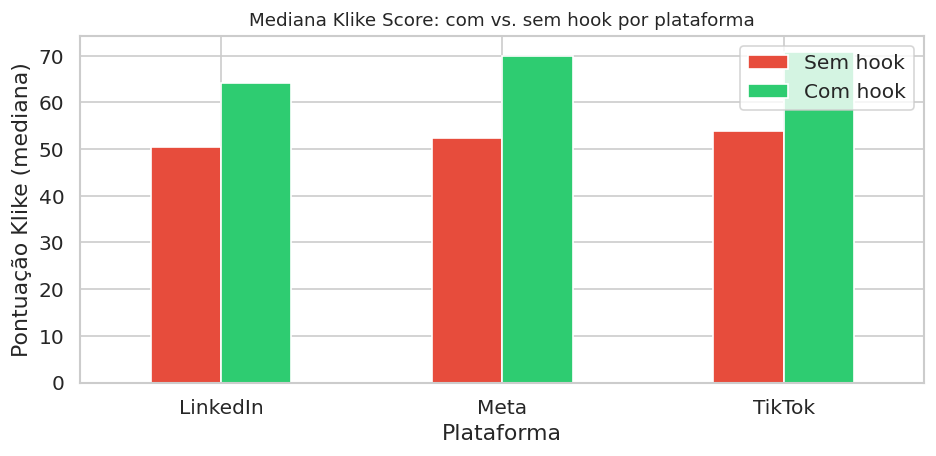

In [58]:
# o efeito do hook é uniforme ou varia por plataforma?
hook_plat = (
    df.groupby(['plataforma', 'tem_hook'])['pontuacao_klike']
      .median()
      .unstack('tem_hook')
      .rename(columns={True: 'Com hook', False: 'Sem hook'})
)

fig, ax = plt.subplots(figsize=(8, 4))
hook_plat.plot(kind='bar', ax=ax, color=['#e74c3c', '#2ecc71'], edgecolor='white')
ax.set_title('Mediana Klike Score: com vs. sem hook por plataforma', fontsize=11)
ax.set_xlabel('Plataforma')
ax.set_ylabel('Pontuação Klike (mediana)')
ax.tick_params(axis='x', rotation=0)
ax.legend(title='')
plt.tight_layout()
plt.show()

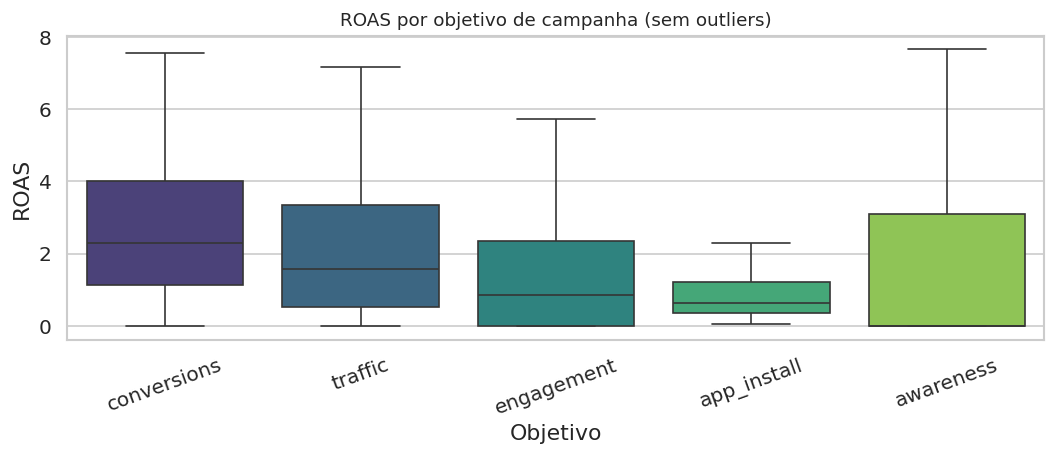

In [59]:
# qual objetivo é mais lucrativo?
fig, ax = plt.subplots(figsize=(9, 4))
ordem_obj = df.groupby('objetivo')['roas'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='objetivo', y='roas', order=ordem_obj,
            palette='viridis', ax=ax, showfliers=False)
ax.set_title('ROAS por objetivo de campanha (sem outliers)', fontsize=11)
ax.set_xlabel('Objetivo')
ax.set_ylabel('ROAS')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

In [ ]:
# as campanhas de retargeting performam melhor?
retarg = df.groupby('e_retargeting')[['roas', 'taxa_cliques', 'pontuacao_klike']].median().round(3)
retarg.index = retarg.index.map({True: 'Retargeting', False: 'Novo'})
print('Mediana por tipo (retargeting vs. novo): ')
retarg

Mediana por tipo (retargeting vs. novo):


,roas,taxa_cliques,pontuacao_klike
e_retargeting,,,
Novo,1.27,0.055,59.9
Retargeting,2.02,0.093,62.4


## 12. Análise de segmentação por faixa etária

> Entender qual faixa etária converte melhor orienta a estratégia de targeting.

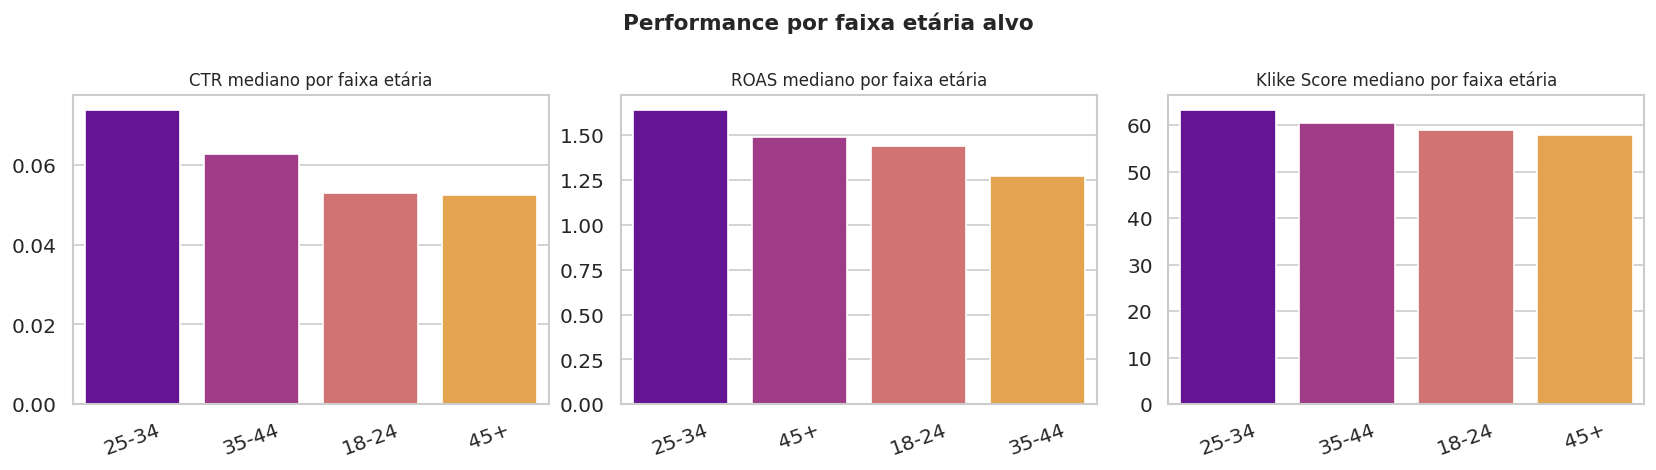

In [61]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
metricas_faixa = ['taxa_cliques', 'roas', 'pontuacao_klike']
titulos_faixa = ['CTR', 'ROAS', 'Klike Score']

for ax, met, tit in zip(axes, metricas_faixa, titulos_faixa):
    dados = df.groupby('faixa_etaria_alvo')[met].median().sort_values(ascending=False)
    sns.barplot(x=dados.index, y=dados.values, palette='plasma', ax=ax)
    ax.set_title(f'{tit} mediano por faixa etária', fontsize=10)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=20)

plt.suptitle('Performance por faixa etária alvo', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 13. Resumo executivo 

Dados consolidados

In [63]:
print('\n[1] QUALIDADE DOS DADOS')
print(f'• {len(df)} campanhas, {len(df.columns)} variáveis')
print(f'• Colunas com nulos: {len(missing)} ({missing.index.tolist()})')
print(f'• Nenhuma linha duplicada')
print(f'• CTR calculado manualmente bate com a coluna original (erro max < 0.001)')

print('\n[2] PLATAFORMA COM MELHOR PERFORMANCE')
melhor_roas = df.groupby('plataforma')['roas'].median().idxmax()
melhor_klike = df.groupby('plataforma')['pontuacao_klike'].median().idxmax()
print(f'• Melhor ROAS mediano: {melhor_roas}')
print(f'• Maior Klike Score mediano: {melhor_klike}')

print('\n[3] ATRIBUTOS CRIATIVOS')
top_atributo = df_impact.iloc[0]
print(f'• Atributo com maior impacto positivo: {top_atributo["atributo"]} (delta={top_atributo["delta"]:+.1f} pts)')
print(f'• Hook presente em {df["tem_hook"].mean():.0%} das campanhas')
print(f'• CTA presente em {df["tem_cta"].mean():.0%} das campanhas')

print('\n[4] CORRELAÇÕES COM KLIKE SCORE')
for var, val in correlacao_klike.head(4).items():
    print(f'• {var}: r={val:.2f}')

print('\n[5] RETARGETING')
r_true  = df[df['e_retargeting'] == True]['pontuacao_klike'].median()
r_false = df[df['e_retargeting'] == False]['pontuacao_klike'].median()
print(f'• Klike Score mediano — retargeting: {r_true:.1f} | novo: {r_false:.1f}')


[1] QUALIDADE DOS DADOS
• 500 campanhas, 27 variáveis
• Colunas com nulos: 7 (['tem_legenda', 'duracao_video_s', 'proporcao_musica_voz', 'taxa_engajamento', 'custo_por_clique', 'tempo_medio_visualizacao_s', 'receita'])
• Nenhuma linha duplicada
• CTR calculado manualmente bate com a coluna original (erro max < 0.001)

[2] PLATAFORMA COM MELHOR PERFORMANCE
• Melhor ROAS mediano: TikTok
• Maior Klike Score mediano: TikTok

[3] ATRIBUTOS CRIATIVOS
• Atributo com maior impacto positivo: tem_hook (delta=+17.3 pts)
• Hook presente em 51% das campanhas
• CTA presente em 69% das campanhas

[4] CORRELAÇÕES COM KLIKE SCORE
• tem_hook: r=0.55
• taxa_cliques: r=0.50
• tem_rosto: r=0.39
• tem_cta: r=0.24

[5] RETARGETING
• Klike Score mediano — retargeting: 62.4 | novo: 59.9
